centrality
- Degree
- Betweenness
- Pagerank
- CI

In [92]:
'''centrality '''
from copy import deepcopy
from typing import Callable
import igraph as ig
import random
from utils.heuristics import Degree,Betweenness,PageRank,CollectiveInfluence

def CentralityAdaptive(g:ig.Graph,heuristic:Callable,step_ratio=None,max_iterations=None,**kwargs):
    '''
    heuristic: optional[Degree,Betweenness,PageRank,CollectiveInfluence]
    return the heuristic based node list using static_id attribute to track original IDs
    '''
    if step_ratio == None: 
        step_ratio = 1/g.vcount()
    if max_iterations is None:
        max_iterations = 1/step_ratio

    g_copy = deepcopy(g)    
    # Add static_id attribute to track original node IDs
    g_copy.vs['static_id'] = list(range(g.vcount()))
    iteration = 0
    result = []

    while g_copy.vcount() > 0 and g_copy.ecount() > 0 and iteration < max_iterations:
        # calculate how many nodes to remove
        k = max(1, int(g_copy.vcount() * step_ratio))
        
        # get top k nodes from current graph
        cur_node_list = heuristic(g_copy, k, **kwargs)
        
        # map back to original node IDs using static_id attribute
        original_node_ids = [g_copy.vs[node]['static_id'] for node in cur_node_list]
        result.extend(original_node_ids)
        
        # remove nodes from graph copy (static_id is automatically maintained for remaining nodes)
        g_copy.delete_vertices(cur_node_list)
        iteration += 1
    return result


# Test the heuristic functions
print("Testing heuristic methods...")
g_test = ig.Graph([(0,1),(0,2),(0,3),(1,3),(2,4),(3,4)])
print(f"Test graph: {g_test.vcount()} nodes, {g_test.ecount()} edges")
print(f"Degrees: {g_test.degree()}")

random.seed(0)
g_test = ig.Graph.Erdos_Renyi(n=10, p=0.2)
print(f"Test graph: {g_test.vcount()} nodes, {g_test.ecount()} edges")
print("\nTesting CentralityAdaptive with different methods...")
print(f"Adaptive Degree centrality result: {CentralityAdaptive(g_test, Degree, step_ratio=0.3)}")
print(f"Adaptive Betweenness centrality result: {CentralityAdaptive(g_test, Betweenness, step_ratio=0.3)}")
print(f"Adaptive PageRank centrality result: {CentralityAdaptive(g_test, PageRank, step_ratio=0.3)}")
print(f"Adaptive CI centrality result: {CentralityAdaptive(g_test, CollectiveInfluence, step_ratio=0.3,radius = 3)}")


Testing heuristic methods...
Test graph: 5 nodes, 6 edges
Degrees: [3, 2, 2, 3, 2]
Test graph: 10 nodes, 13 edges

Testing CentralityAdaptive with different methods...
Adaptive Degree centrality result: [2, 0, 1, 5, 3, 4]
Adaptive Betweenness centrality result: [1, 2, 4, 7, 0, 3]
Adaptive PageRank centrality result: [2, 1, 4, 5, 0]
Adaptive CI centrality result: [1, 0, 3, 2, 4, 5]


## MultiStage dismantling

### Stage 1: Preprocess


### Stage 2: Dismantling

In [93]:
# COPY from MIND_ND/validate.py and test_single.py
def MIND(graph,step_ratio=None,ckpt_pth='saved/mind.ckpt'):
    from networks.dismantle import SACPolicy
    import torch
    from copy import deepcopy
    from scipy.integrate import simpson
    from utils.graph_data import Batch, ig_to_data

    device: str='cuda:0'
    # device = torch.device('cpu')
    # Load policy
    sac = SACPolicy(
        num_features=16,
        num_heads=4,
        num_mps=6,
    ).to(device)
    sac.load_state_dict(torch.load(ckpt_pth)['policy_state_dict'])
    policy = sac

    # Make a copy and initialize tracking
    g = deepcopy(graph)
    n_init = g.vcount()
    g.vs["i_init"] = list(range(n_init))
    
    policy.eval()

    gcc_eps = []  # LCC size/n_init at each step, note: the start 1 is ignored
    lcc_sizes = [g.connected_components().giant().vcount()]  # LCC size at each step,start from 
    removals = []  # Removed node IDs (original)
    

    # Calculate step size
    if step_ratio is not None and step_ratio > 0:
        step_size = max(int(step_ratio * n_init), 1)
    else:
        step_size = 1

    # Main dismantling loop
    finished = False
    while not finished:
        # Get action probabilities from policy
        with torch.no_grad():
            batch_data = Batch(device, [ig_to_data(g)])
            _, log_probs = policy.get_action(batch_data, val=True)
        
        # Convert to probabilities and get top-k nodes
        probs = log_probs.exp().cpu().numpy()
        
        # Select top step_size nodes based on probabilities
        current_step = min(step_size, len(probs))
        top_k_indices = np.argsort(-probs)[:current_step]
        
        # Remove nodes sequentially
        for idx in sorted(top_k_indices, reverse=True):  # Remove in reverse order to avoid index shifts
            if idx < g.vcount():  # Safety check
                original_id = g.vs[idx]["i_init"]
                removals.append(original_id)
                g.delete_vertices(idx)
                # Check termination condition
                lcc_size = g.connected_components().giant().vcount()
                lcc_sizes.append(lcc_size)
                gcc_eps.append(lcc_size / n_init)
                if lcc_size / n_init < 0.1 or g.ecount() == 0:
                    finished = True
                    break
    
    # Calculate metrics
    auc = simpson(gcc_eps, dx=1)
    robustness = sum(gcc_eps[::-1][:-1]) / n_init
    
    return auc, robustness, gcc_eps, lcc_sizes, removals,step_size


In [94]:
from typing import Callable,Dict
import numpy as np
  
def dismantling(g:ig.Graph,dismantling_method,**kwargs):
    '''
    same return with preprocess
    removed_nodes: complete solution
    removed_sizes: cumulative removed number at each step, start from 0
    lcc_sizes: lcc size at each step, len(lcc_sizes) = len(removed_sizes)
    '''
    g = deepcopy(g)

    # Implementation
    if dismantling_method is None:
        dismantling_method = CentralityAdaptive
        #TODO defalut kwargs


    # If using CentralityAdaptive, pass the centrality and step_ratio
    if dismantling_method == CentralityAdaptive:
        result = dismantling_method(g, **kwargs)

    # elif dismantling_method == FINDER:
    #     result = dismantling_method(g, **kwargs)
        
    elif dismantling_method == MIND:
        auc, robustness, _, lcc_sizes, removals, step_size = dismantling_method(g, **kwargs)
        # construct the return
        removed_nodes = removals
        removed_sizes = np.arange(0,len(removals),step_size).tolist()
        if removed_sizes[-1] != len(removals):
            removed_sizes.append(len(removals))
        lcc_sizes = [lcc_sizes[n] for n in removed_sizes]
    
    #map static id to result if static_id is provided
    for i,node_id in enumerate(removed_nodes):
        # Use static_id to get the true original node ID
        if 'static_id' in g.vs.attributes():
            original_node_id = g.vs[node_id]['static_id']
        else:
            original_node_id = node_id
        removed_nodes[i] = original_node_id
    
    return auc, robustness, removed_nodes, removed_sizes, lcc_sizes

# Test the dismantling functions
print("Testing dismantling methods...")
g_test = ig.Graph([(0,1),(0,2),(0,3),(1,3),(2,4),(3,4)])
print(f"Test graph: {g_test.vcount()} nodes, {g_test.ecount()} edges")
_, _, test_removed_nodes, test_removed_sizes, test_lcc_sizes = dismantling(g_test,MIND,step_ratio=0.0025)
assert len(test_removed_sizes)==len(test_lcc_sizes)


Testing dismantling methods...
Test graph: 5 nodes, 6 edges


# baselines

  Running CoreHD...
method CoreHD dismantling time:  0.014698982238769531
  Running Spectral...
method Spectral dismantling time:  1.8269693851470947


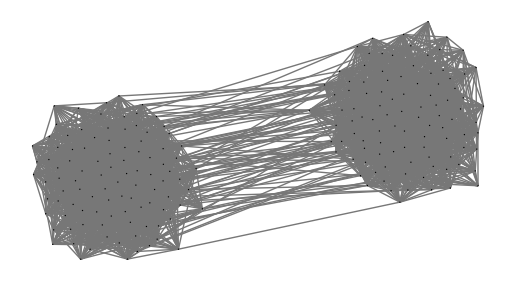

<Figure size 600x400 with 0 Axes>

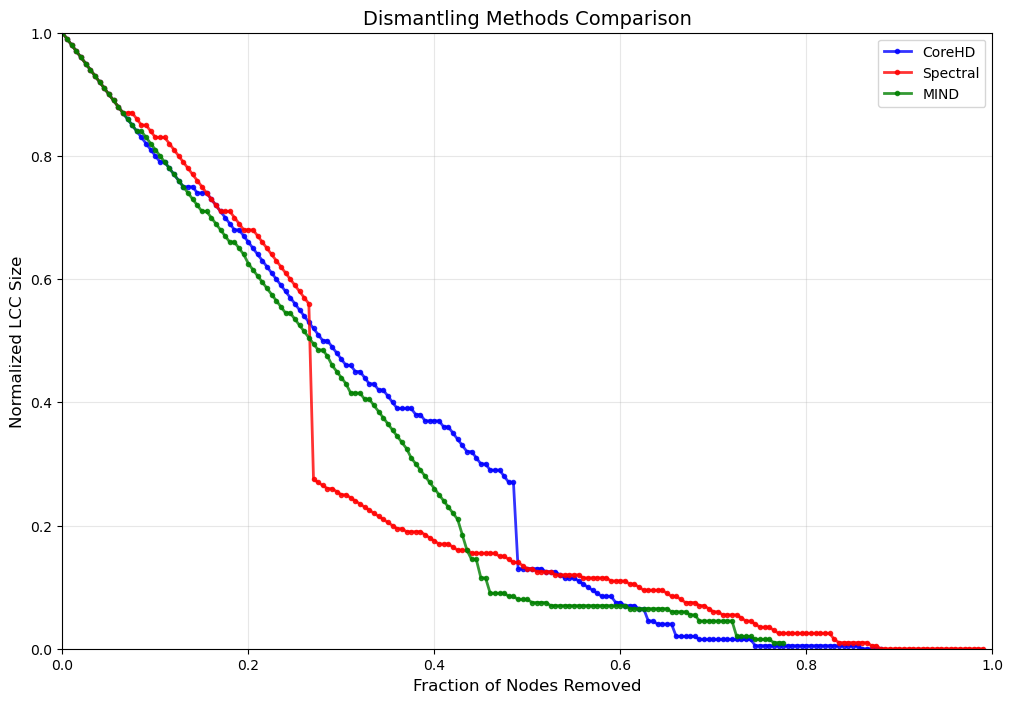

In [96]:
import importlib
import baseline
importlib.reload(baseline)
from baseline import baseline_dismantling,METHODS

pref_matrix = [[0.3, 0.01], [0.01, 0.3]]
G_sbm = ig.Graph.SBM(n=200, pref_matrix=pref_matrix, block_sizes=[100, 100])
G_sbm.vs['static_id'] = list(range(100)) # Keep track of original IDs
plot_graph(G_sbm)

methods = {
    "CoreHD": METHODS['CoreHD'],
    "Spectral":METHODS['Spectral'],
}

baseline_results = baseline_dismantling(G_sbm,methods,visualize=False)

# Compare with MIND
auc, robustness, removed_nodes, removed_sizes, lcc_sizes = dismantling(
    G_sbm,
    MIND,
    step_ratio = 0
)

all_results = baseline_results
all_results['MIND'] = removed_nodes

from visualize_dismantling import visualize_multiple_curve
visualize_multiple_curve(G_sbm,all_results)



method CoreHD dismantling time:  0.005801200866699219
method Spectral dismantling time:  0.13225102424621582
method Adaptive Degree dismantling time:  0.0
method BPD dismantling time:  5.753098249435425


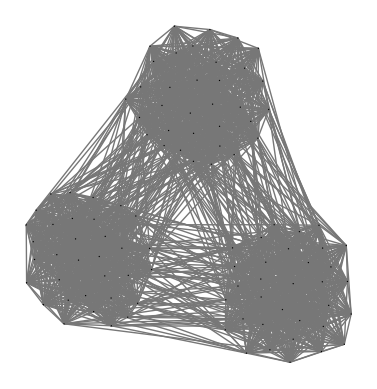

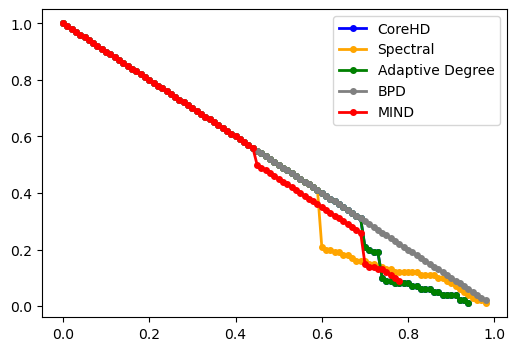

{}

In [88]:
import importlib
import graphs
importlib.reload(graphs.gen_switched_graphs)
# from graph_analysis import statistics
from graphs.gen_switched_graphs import stochastic_block_model
G_sbm = stochastic_block_model(N=100)
G_sbm.vs['static_id'] = list(range(100)) # Keep track of original IDs
plot_graph(G_sbm)
# statistics(G_sbm)
benchmark_dismantling(G_sbm, methods)

In [81]:
np.random.rand()

0.7829169232207657

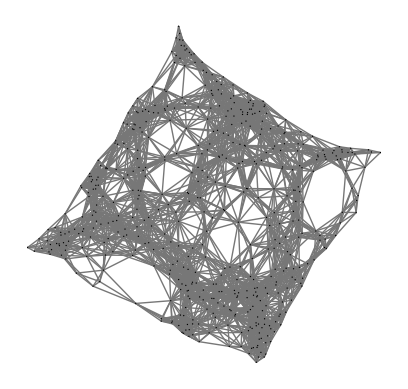

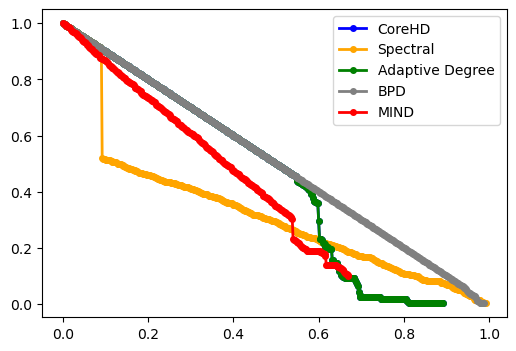

{}

In [53]:
# Setup SBM
# Generate a 2D Random Geometric Graph
# n=500 nodes, radius=0.12 (threshold for connectivity)
G_rgg = ig.Graph.GRG(n=500, radius=0.12)
G_rgg.vs['static_id'] =list(range(G_rgg.vcount())) 
plot_graph(G_rgg)
benchmark_dismantling(G_rgg, methods)

method CoreHD dismantling time:  0.0009982585906982422
method Spectral dismantling time:  0.6260161399841309
method Adaptive Degree dismantling time:  0.0010013580322265625
method BPD dismantling time:  0.09661102294921875


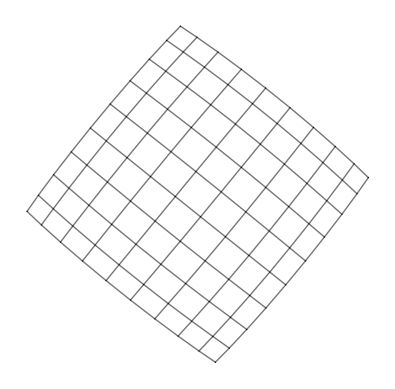

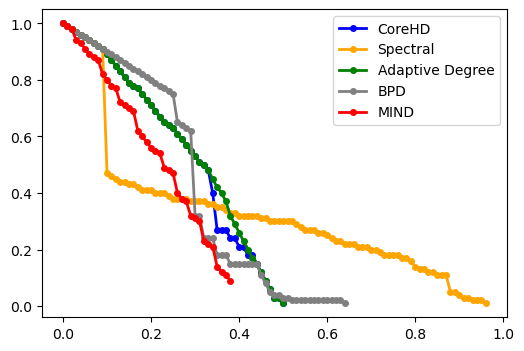

In [65]:

G_grid = ig.Graph.Lattice([10, 10], circular=False)
# Run on a Grid or SBM
G_grid.vs['static_id'] = list(range(G_grid.vcount()))
plot_graph(G_grid)
data = benchmark_dismantling(G_grid, methods)
